<a href="https://colab.research.google.com/github/mohithsangeetham/linkedin_daily_post_agent/blob/adding_gemini_agent_for_image_creation/linkedin_daily_post_agent.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 📝 Daily LinkedIn Post Agent — AI / Tech / Data Science

**What this notebook does:**
1. Pulls fresh tech/AI news from Hacker News + arXiv
2. Picks a daily topic from a rotating bank (no repeats for 7 days)
3. Uses **Claude** to draft a LinkedIn post in your voice
4. Uses **Gemini Nano Banana 2** (`gemini-3.1-flash-image-preview`) to generate a matching LinkedIn image
5. Emails the draft + image to you for review & approval

**How to use:** Run all cells in order. Schedule daily via Colab Pro Scheduled Notebooks.

## 1️⃣ Install dependencies

In [1]:
!pip install -q anthropic feedparser requests google-genai Pillow

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 753.6/753.6 kB 39.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 81.5/81.5 kB 10.1 MB/s eta 0:00:00


## 2️⃣ Configure secrets

Add these four secrets via the 🔑 **Secrets** tab in the left sidebar.
Each secret needs **Notebook access toggled ON (blue)**.

| Secret Name (type exactly) | What it is |
|---|---|
| `ANTHROPIC_API_KEY` | Claude API key from console.anthropic.com |
| `GEMINI_API_KEY` | Google AI Studio key from aistudio.google.com |
| `GMAIL_ADDRESS` | Your Gmail address |
| `GMAIL_APP_PASSWORD` | 16-char Gmail App Password from myaccount.google.com/apppasswords |

> ⚠️ Never paste actual values into the code. Always use Colab Secrets.

In [2]:
from google.colab import userdata
import os

os.environ['ANTHROPIC_API_KEY'] = userdata.get('ANTHROPIC_API_KEY')
os.environ['GEMINI_API_KEY']    = userdata.get('GEMINI_API_KEY')
GMAIL_ADDRESS      = userdata.get('GMAIL_ADDRESS')
GMAIL_APP_PASSWORD = userdata.get('GMAIL_APP_PASSWORD')
RECIPIENT_EMAIL    = GMAIL_ADDRESS

print('✅ Secrets loaded')

✅ Secrets loaded


## 3️⃣ Personalize your voice & topics

**Edit this cell.** The more specific you are, the better Claude sounds like you.

In [3]:
# === YOUR PROFILE ===
YOUR_NAME     = "Your Name"
YOUR_ROLE     = "Data Scientist / ML Engineer"
YOUR_AUDIENCE = "data scientists, ML engineers, and tech professionals"

# === YOUR VOICE ===
YOUR_TONE = """
- Conversational and direct, not corporate or salesy
- Practical insights over hype
- First-person perspective ("I noticed...", "In my experience...")
- Mix of curiosity and quiet confidence
- Avoid: buzzwords (synergy, leverage, paradigm shift), excessive emojis, hashtag stuffing
- Short paragraphs (1-2 sentences) for readability
- NO em dashes, NO "In today's fast-paced world", NO "Let's dive in"
"""

# === TOPIC BANK ===
TOPIC_CATEGORIES = [
    "recent breakthrough in LLM research or capabilities",
    "practical data science tip or workflow improvement",
    "MLOps / production ML insight",
    "AI tool review or comparison (open-source preferred)",
    "career advice for data scientists or ML engineers",
    "reflection on a common ML mistake or anti-pattern",
    "emerging trend in AI/tech worth paying attention to",
    "breakdown of a key ML/statistics concept in plain language",
    "opinion on AI ethics, safety, or societal impact",
    "deep dive into a Python library or data tool",
]

print(f'✅ Profile set for {YOUR_NAME} — {len(TOPIC_CATEGORIES)} topic categories loaded')

✅ Profile set for Your Name — 10 topic categories loaded


## 4️⃣ Topic rotation (no repeats for 7 days)

In [4]:
from google.colab import drive
import json, os, random
from datetime import datetime, timedelta

drive.mount('/content/drive', force_remount=False)

HISTORY_DIR  = '/content/drive/MyDrive/linkedin_agent'
HISTORY_FILE = f'{HISTORY_DIR}/topic_history.json'
os.makedirs(HISTORY_DIR, exist_ok=True)

def load_history():
    if os.path.exists(HISTORY_FILE):
        with open(HISTORY_FILE) as f:
            return json.load(f)
    return []

def save_history(history):
    with open(HISTORY_FILE, 'w') as f:
        json.dump(history, f, indent=2)

def pick_topic():
    history = load_history()
    cutoff  = datetime.now() - timedelta(days=7)
    recent  = {h['topic'] for h in history if datetime.fromisoformat(h['date']) > cutoff}
    available = [t for t in TOPIC_CATEGORIES if t not in recent] or TOPIC_CATEGORIES
    topic = random.choice(available)
    history.append({'date': datetime.now().isoformat(), 'topic': topic})
    save_history(history[-30:])
    return topic

todays_topic = pick_topic()
print(f'🎯 Today\'s topic: {todays_topic}')

Mounted at /content/drive
🎯 Today's topic: practical data science tip or workflow improvement


## 5️⃣ Fetch fresh news (Hacker News + arXiv)

In [5]:
import requests, feedparser

def fetch_hackernews_top(n=5):
    ids = requests.get('https://hacker-news.firebaseio.com/v0/topstories.json', timeout=10).json()[:30]
    stories  = []
    keywords = ['ai', 'ml', 'llm', 'gpt', 'claude', 'python', 'data', 'model', 'neural',
                'machine learning', 'deep learning', 'transformer', 'agent', 'rag',
                'embedding', 'open source', 'github']
    for sid in ids:
        try:
            s     = requests.get(f'https://hacker-news.firebaseio.com/v0/item/{sid}.json', timeout=5).json()
            title = (s.get('title') or '').lower()
            if any(k in title for k in keywords):
                stories.append({'title': s.get('title'),
                                'url':   s.get('url', f'https://news.ycombinator.com/item?id={sid}'),
                                'score': s.get('score', 0)})
            if len(stories) >= n:
                break
        except Exception:
            continue
    return stories

def fetch_arxiv_recent(n=3):
    url  = ('http://export.arxiv.org/api/query?search_query=cat:cs.LG+OR+cat:cs.AI+OR+cat:cs.CL'
            '&sortBy=submittedDate&sortOrder=descending&max_results=' + str(n))
    feed = feedparser.parse(url)
    return [{'title': e.title, 'summary': e.summary[:300], 'url': e.link} for e in feed.entries]

hn_stories    = fetch_hackernews_top(5)
arxiv_papers  = fetch_arxiv_recent(3)

print(f'📰 Pulled {len(hn_stories)} HN stories + {len(arxiv_papers)} arXiv papers')
for s in hn_stories[:3]:
    print(f'  • [{s["score"]}] {s["title"]}')

📰 Pulled 5 HN stories + 3 arXiv papers
  • [663] Local AI needs to be the norm
  • [124] Running local models on an M4 with 24GB memory
  • [6] The Greatest Shot in Television: James Burke Had One Chance to Nail This Scene


## 6️⃣ Generate the post with Claude

In [6]:
from anthropic import Anthropic

client = Anthropic()

news_context = '## Today\'s tech/AI news (Hacker News):\n'
for s in hn_stories:
    news_context += f'- {s["title"]} ({s["url"]})\n'
news_context += '\n## Recent arXiv papers:\n'
for p in arxiv_papers:
    news_context += f'- {p["title"]}\n  Summary: {p["summary"][:200]}...\n'

system_prompt = f"""You are a ghostwriter crafting LinkedIn posts for {YOUR_NAME}, a {YOUR_ROLE}.

Audience: {YOUR_AUDIENCE}

Voice guidelines:
{YOUR_TONE}

LinkedIn best practices:
- Strong hook in first 1-2 lines (truncated after ~210 chars on mobile)
- 150-280 words total
- Short paragraphs with white space
- End with a question or discussion invite
- 3-5 relevant lowercase hashtags at the end"""

user_prompt = f"""Write today's LinkedIn post.

**Topic:** {todays_topic}

**Today's tech context (use ONLY if genuinely relevant):**
{news_context}

Return ONLY the post text. No preamble, no explanation. Start directly with the hook."""

response = client.messages.create(
    model='claude-opus-4-7',
    max_tokens=1024,
    system=system_prompt,
    messages=[{'role': 'user', 'content': user_prompt}]
)

draft = response.content[0].text.strip()
print('=' * 60)
print('📝 DRAFT POST')
print('=' * 60)
print(draft)
print('=' * 60)
print(f'Word count: {len(draft.split())}')

📝 DRAFT POST
Most of my model debugging time used to vanish into one black hole: figuring out which version of which dataset produced which result.

I'd open a notebook from three weeks ago, see "v2_final_cleaned.csv", and feel my soul leave my body.

What actually fixed it wasn't a fancy tool. It was one rule: every experiment logs a hash of the input data alongside the metrics.

Three lines of code:

```
import hashlib
data_hash = hashlib.md5(df.to_csv().encode()).hexdigest()[:8]
mlflow.log_param("data_hash", data_hash)
```

Now when a teammate says "I can't reproduce your AUC", I check the hash in 5 seconds. Either we're working with different data, or it's a real bug worth chasing.

It sounds almost too simple, but the number of "mystery" discrepancies that turned out to be silent data drift, an updated upstream table, or someone re-running an ETL was genuinely embarrassing.

A few small things I added later:
- Hash the schema separately from the rows (helps spot column changes)
- 

## 7️⃣ Generate LinkedIn image with Gemini Nano Banana 2

Uses `gemini-3.1-flash-image-preview` (Nano Banana 2) to create a professional
LinkedIn image that visually matches your post. Output is saved as a 1280×720 PNG
optimised for LinkedIn's feed format.

📄 Post sent directly to Gemini as image input
(215 words from Claude → Gemini Nano Banana 2)

⏳ Generating image with Gemini Nano Banana 2 (gemini-3.1-flash-image-preview)...
✅ Image saved: /content/linkedin_post_image.png (1280x720px)

🖼️ Preview:


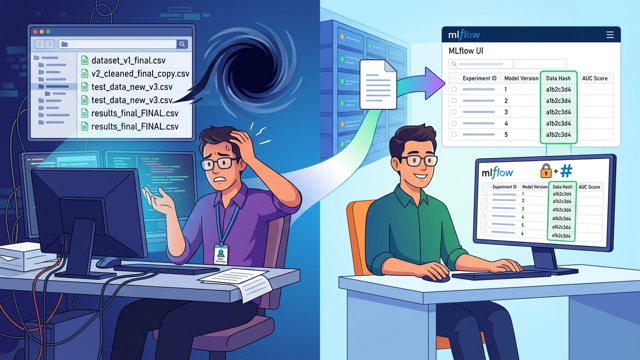

In [7]:
from google import genai as ggenai
from google.genai import types as gtypes
from PIL import Image
import io, base64
from IPython.display import display

IMAGE_PATH = '/content/linkedin_post_image.png'

# Direct approach: pass the Claude-generated post text straight into Gemini.
# No middleman, no prompt rewriting — Gemini reads the actual post
# and decides what image best represents it. Maximum content alignment.
image_prompt = (
    'Create a professional 16:9 landscape image for a LinkedIn post. '
    'Visually represent the content below. '
    'Do NOT include any text, words, letters, or numbers in the image.\n\n'
    + draft
)

print('📄 Post sent directly to Gemini as image input')
print(f'({len(draft.split())} words from Claude → Gemini Nano Banana 2)')
print()

# Generate image with Gemini Nano Banana 2
gclient = ggenai.Client(api_key=os.environ['GEMINI_API_KEY'])

print('⏳ Generating image with Gemini Nano Banana 2 (gemini-3.1-flash-image-preview)...')

img_response = gclient.models.generate_content(
    model='gemini-3.1-flash-image-preview',
    contents=image_prompt,
    config=gtypes.GenerateContentConfig(
        response_modalities=['IMAGE'],
        image_config=gtypes.ImageConfig(
            aspect_ratio='16:9',
        ),
    ),
)

# Step 3: Extract and save the image
generated_image = None
for part in img_response.parts:
    if part.inline_data:
        img_bytes = part.inline_data.data
        generated_image = Image.open(io.BytesIO(img_bytes))
        break

if generated_image is None:
    raise ValueError('No image returned from Gemini. Check your API key and billing.')

# Resize to LinkedIn optimal resolution (1280x720)
generated_image = generated_image.resize((1280, 720), Image.LANCZOS)
generated_image.save(IMAGE_PATH, 'PNG', optimize=True)

print(f'✅ Image saved: {IMAGE_PATH} ({generated_image.size[0]}x{generated_image.size[1]}px)')
print('\n🖼️ Preview:')
display(generated_image.resize((640, 360)))  # half-size preview in notebook

## 8️⃣ Email the draft + image to yourself

In [8]:
import smtplib, base64
from email.mime.text import MIMEText
from email.mime.multipart import MIMEMultipart
from email.mime.image import MIMEImage
from datetime import date

def send_email_with_image(subject, plain_body, html_body, image_path):
    msg = MIMEMultipart('mixed')
    msg['Subject'] = subject
    msg['From']    = GMAIL_ADDRESS
    msg['To']      = RECIPIENT_EMAIL

    # Text + HTML body
    alt_part = MIMEMultipart('alternative')
    alt_part.attach(MIMEText(plain_body, 'plain'))
    alt_part.attach(MIMEText(html_body,  'html'))
    msg.attach(alt_part)

    # Attach image as inline + attachment
    with open(image_path, 'rb') as img_file:
        img_data = img_file.read()

    img_mime = MIMEImage(img_data, 'png')
    img_mime.add_header('Content-ID', '<linkedin_image>')
    img_mime.add_header('Content-Disposition', 'attachment', filename='linkedin_post_image.png')
    msg.attach(img_mime)

    with smtplib.SMTP_SSL('smtp.gmail.com', 465) as server:
        server.login(GMAIL_ADDRESS, GMAIL_APP_PASSWORD)
        server.send_message(msg)

today_str = date.today().strftime('%A, %b %d')

html = f"""
<html><body style='font-family:-apple-system,sans-serif;max-width:640px;margin:0 auto;'>
  <h2 style='color:#0a66c2;'>📝 LinkedIn draft — {today_str}</h2>
  <p><b>Topic:</b> {todays_topic}</p>
  <hr style='border:none;border-top:1px solid #eee;'>

  <h3 style='color:#333;'>Post text</h3>
  <div style='background:#f6f8fa;padding:20px;border-radius:8px;white-space:pre-wrap;
              font-size:15px;line-height:1.6;border-left:4px solid #0a66c2;'>{draft}</div>
  <p style='color:#888;font-size:13px;'>Word count: {len(draft.split())}</p>

  <hr style='border:none;border-top:1px solid #eee;'>
  <h3 style='color:#333;'>Generated image</h3>
  <p style='color:#555;font-size:13px;'>Image prompt used: <em>{image_prompt}</em></p>
  <img src='cid:linkedin_image' style='width:100%;border-radius:8px;margin-top:8px;'>
  <p style='color:#888;font-size:12px;margin-top:8px;'>1280×720px PNG attached — save and upload to LinkedIn.</p>

  <hr style='border:none;border-top:1px solid #eee;'>
  <p style='color:#aaa;font-size:12px;'>Generated by your Colab LinkedIn Agent · Claude + Gemini Nano Banana 2</p>
</body></html>
"""

plain = f"LinkedIn draft — {today_str}\n\nTopic: {todays_topic}\n\n{'='*60}\n\n{draft}\n\n{'='*60}\nImage attached as linkedin_post_image.png"

send_email_with_image(
    subject=f'📝 LinkedIn draft + image — {date.today().strftime("%b %d")}',
    plain_body=plain,
    html_body=html,
    image_path=IMAGE_PATH
)

print(f'✅ Email sent to {RECIPIENT_EMAIL}')
print('📎 Image attached as linkedin_post_image.png')

✅ Email sent to mohithsangeetham@gmail.com
📎 Image attached as linkedin_post_image.png


## 🚀 Next steps

**To automate daily:**
- Colab Pro → ⚙️ Settings → **Scheduled notebooks** → set to 7am daily
- Alternative: GitHub Actions free cron (ask for that version if needed)

**Model used:**
- Text: `claude-opus-4-7` (Claude)
- Image: `gemini-3.1-flash-image-preview` (Gemini Nano Banana 2)

**Cost per run (approx):**
- Claude: ~$0.02 per post
- Gemini image: ~$0.03 per image
- **Total: ~$0.05 per day / ~$1.50/month**

**How to post:**
1. Open the email → read and tweak the draft text
2. Save the attached `linkedin_post_image.png`
3. On LinkedIn: start a post → upload the image → paste the text → post

**To improve over time:**
- Paste 2-3 of your best posts as few-shot examples in the system prompt (Cell 6)
- Adjust `TOPIC_CATEGORIES` based on what gets engagement
- Swap `claude-opus-4-7` → `claude-haiku-4-5-20251001` to cut costs by 20x